In [1]:
import pandas as pd
from Import_data import import_df_description, Make_path_list
from Parameters import subject_to_pop, path_directory, dict_category_all, path_excel, th_bad_channel
from Tools import  find_participant,get_only_eeg, df_to_mne_events2
import mne
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
path_data, path_stim, path_answers = Make_path_list(path_directory,subject_to_pop)

In [3]:
df = import_df_description(path_stim,path_answers,dict_category_all,path_excel,subject_to_pop)

c:\Users\hugop\Desktop\Code_Iconic\Scripts\Import_data.py:201: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sommail"] = df["sommail"].replace(map)
c:\Users\hugop\Desktop\Code_Iconic\Scripts\Import_data.py:274: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df_tw[col] = list(sub_df_p[col])[0]
c:\Users\hugop\Desktop\Code_Iconic\Scripts\Import_data.py:274: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

In [4]:
df[df["subjects"] == 'S01']

,id_stim,time_stim,id_answer,time_answer,latency,size_category,subjects,Epochs,liste,gender,age,sleep,neural_disease,medication,mean_latency,std_latency,Good_answers_rate,max_latency,min_latency
0,3.0,11.6934,300.0,12.4265,0.7331,good,S01,Epoch_0,1.0,F,22.0,2,0,0,0.93775,0.240867,0.81875,1.7,0.5688
1,3.0,16.7266,300.0,17.4172,0.6906,good,S01,Epoch_1,1.0,F,22.0,2,0,0,0.93775,0.240867,0.81875,1.7,0.5688
2,2.0,21.7598,200.0,22.4831,0.7233,good,S01,Epoch_2,1.0,F,22.0,2,0,0,0.93775,0.240867,0.81875,1.7,0.5688
3,3.0,31.8613,300.0,32.8176,0.9563,good,S01,Epoch_3,1.0,F,22.0,2,0,0,0.93775,0.240867,0.81875,1.7,0.5688
4,2.0,36.9277,200.0,37.7913,0.8636,good,S01,Epoch_4,1.0,F,22.0,2,0,0,0.93775,0.240867,0.81875,1.7,0.5688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,2.0,981.1620,200.0,982.1120,0.9500,good,S01,Epoch_126,1.0,F,22.0,2,0,0,0.93775,0.240867,0.81875,1.7,0.5688
127,4.0,987.4120,400.0,988.6863,1.2743,good,S01,Epoch_127,1.0,F,22.0,2,0,0,0.93775,0.240867,0.81875,1.7,0.5688
128,1.0,993.6950,100.0,994.3763,0.6813,good,S01,Epoch_128,1.0,F,22.0,2,0,0,0.93775,0.240867,0.81875,1.7,0.5688
129,4.0,999.9630,400.0,1000.7053,0.7423,good,S01,Epoch_129,1.0,F,22.0,2,0,0,0.93775,0.240867,0.81875,1.7,0.5688


In [5]:
# df_clean = df[df['latency'] < th]
# mean_clean = df_clean['latency'].mean()

In [6]:
# path = path_data[0]
# raw = mne.io.read_raw_bdf(path, preload=True)
# subject = find_participant(path,signe = 'S')

In [7]:
# meta_data = df[df['subjects'] == subject]
# # meta_data = meta_data[['Epochs','latency','time_stim','id_stim']]
# meta_data.index = np.arange(0,len(meta_data))
# meta_data[meta_data['latency'] > th]

In [8]:
# raw_eeg = get_only_eeg(raw)
# raw_eeg.set_montage("biosemi128")
# print()

In [9]:
def find_bad_epoch(df,threshold):
    df_bad_epoch = df[df['latency'] > threshold]
    bad_epoch = list(df_bad_epoch.index)
    return bad_epoch

In [10]:
# mne_events, stim = df_to_mne_events2(raw_eeg,meta_data)

# # On utilise le temps de latence moyen (sans les essais trop lents) pour mettre une limite a la taille de la fenetre 
# epochs_eeg = mne.Epochs(raw_eeg,events = mne_events,event_id = stim,tmin = -0.2,tmax=mean_clean,preload=True)

# bad_epochs = find_bad_epoch(meta_data,th)

# epochs_eeg_clean =  epochs_eeg.copy()
# epochs_eeg_clean = epochs_eeg_clean.drop(bad_epochs)

# epochs_eeg_clean

In [11]:
# average = epochs_eeg_clean.average()

In [12]:
# threshold = 75

def find_bad_channels(evoked, threshold):

    def find_pic(channel,threshold = threshold) :
        for el in channel:
            if el > threshold or el < -threshold :
                return True
        return False
    
    data = evoked.get_data()
    ch_names = evoked.ch_names
    
    bad_channels = []
    for i ,ch in enumerate(data):
        if find_pic(ch, threshold * 1e-6) :
            print(f"channel trop puissant {ch_names[i]}")
            bad_channels.append(ch_names[i])

    return bad_channels

# bad_ch = find_bad_channels(average, threshold)
# average.info['bads'] = bad_ch
# average_clean = average.copy()
# # average_clean.drop_channels(bad_ch)
# average_clean.interpolate_bads()

In [13]:
# mne.viz.plot_evoked(average, hline = [threshold,-threshold],spatial_colors = False,exclude = [], ylim= dict(eeg=[-threshold-20, threshold +20]))
# mne.viz.plot_evoked(average_clean,spatial_colors = True, ylim= dict(eeg=[-threshold, threshold]))
print('yes')

yes


In [14]:
def make_evoked(path_data,df,tmax, threshold_epoch,threshold_channel = 75):
    
    """
    threshold_channel = si un canal a au moins une valeur qui depasse ce seuil, il est considere comme mauvais (a exprimer en micro Volt --> threshold = threshold x 10e-6 V)
    tmax = temps d'une epoch
    threshold_epoch = combien de fois on ajoute l'ecart type a la moyenne pour definir la taille des epochs (mean + threshold_epoch * std)
    """

    raw = mne.io.read_raw_bdf(path_data, preload=True)
    subject = find_participant(path_data,signe = 'S')

    meta_data = df[df['subjects'] == subject]
    meta_data.index = np.arange(0,len(meta_data))

    raw_eeg = get_only_eeg(raw)
    raw_eeg.set_montage("biosemi128")

    mne_events, stim = df_to_mne_events2(raw_eeg,meta_data)
    epochs_eeg = mne.Epochs(raw_eeg,events = mne_events,event_id = stim,tmin = -0.2,tmax=tmax,preload=True) # On utilise le temps de latence moyen (sans les essais trop lents) pour mettre une limite a la taille de la fenetre 
    
    epochs_eeg.set_eeg_reference('average', projection=False)   # on rereference la baseline par rapport a la moyenne
    epochs_eeg.apply_baseline((None, 0))                        # on retire le bruit de la baseline

    mean = df['latency'].mean()
    std = df['latency'].std()
    th = mean + threshold_epoch * std
    bad_epochs = find_bad_epoch(meta_data,th)

    epochs_eeg_clean =  epochs_eeg.copy()
    epochs_eeg_clean = epochs_eeg_clean.drop(bad_epochs)

    average = epochs_eeg_clean.average()

    bad_ch = find_bad_channels(average, threshold_channel)      # seuil etablit a (+ ou -) 75 micro volt
    average.info['bads'] = bad_ch
    average_clean = average.copy()
    average_clean.interpolate_bads()                            # on interpole les cannaux trop bruites

    good_answer_rate = list(meta_data['Good_answers_rate'].unique())
    mean_latency = list(meta_data['mean_latency'].unique())
    return average_clean, mean_latency[0], good_answer_rate[0], bad_ch

def make_evoked_split(path_directory,subject_to_pop,subject_split):
    path_data, path_stim, path_answers = Make_path_list(path_directory,subject_to_pop)
    df = import_df_description(path_stim,path_answers,dict_category_all,path_excel,subject_to_pop)
    
    mean = df['latency'].mean()
    std = df['latency'].std()
    th_bad_epoch = mean + 2.5 * std                 # critere de selection pour definir ce qu'est un 'bad epoch' sur la base du temps de latence entre stimulation et reponse
 
    df_clean = df[df['latency'] < th_bad_epoch]
    tmax = df_clean['latency'].mean()               # utile pour etablir la fenetre de comparaison entre le groupe et l'individu

    group = []
    individual_average = None
    for path in path_data:
        if subject_split == find_participant(path):
            individual_average, mean_latency, good_answer_rate, bad_ch  = make_evoked(path,df,tmax = tmax,threshold_epoch=th_bad_epoch)
        else :
            part_of_group, useless_1, useless_2, useless_3 = make_evoked(path,df,tmax = tmax, threshold_epoch=th_bad_epoch)
            group.append(part_of_group)
    
    group_average = mne.grand_average(group)
    return group_average, individual_average, mean_latency, good_answer_rate, bad_ch

In [15]:
# group_average , individual_average = make_evoked_split(path_directory=path_directory,subject_to_pop=subject_to_pop,subject_split="S01")

In [16]:
def compute_RMSE(test,train,per_channel = False):
    
    if per_channel:
        return np.sqrt(np.mean((test.data - train.data) ** 2, axis=1))
    else :
        return np.sqrt(np.mean((test.data - train.data) ** 2))
    
# def compute_var(test,train) :
    

c:\Users\hugop\Desktop\Code_Iconic\Scripts\Import_data.py:201: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sommail"] = df["sommail"].replace(map)


Extracting BDF parameters from C:\Users\hugop\Desktop\Stage Iconique\Data_stage\EEG data\S01_DS.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 564735  =      0.000 ...  1102.998 secs...


c:\Users\hugop\Desktop\Code_Iconic\Scripts\Import_data.py:274: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df_tw[col] = list(sub_df_p[col])[0]
c:\Users\hugop\Desktop\Code_Iconic\Scripts\Import_data.py:274: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df_tw[col] = list(sub_df_p[col])[0]
c:\Users\hugop\Desktop\Code_Iconic\Scripts\Import_data.py:274: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

Used Annotations descriptions: [np.str_('A'), np.str_('B'), np.str_('C')]
Not setting metadata
131 matching events found
Setting baseline interval to [-0.19921875, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 131 events and 591 original time points ...
0 bad epochs dropped
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Applying baseline correction (mode: mean)
Dropped 8 epochs: 13, 29, 31, 45, 68, 88, 103, 113
channel trop puissant A16
channel trop puissant D31
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 126 sensor positions
Interpolating 2 sensors
Extracting BDF parameters from C:\Users\hugop\Desktop\Stage Iconique\Data_stage\EEG data\S02_DS.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 5212

C:\Users\hugop\AppData\Local\Temp\ipykernel_22412\3351899741.py:37: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  average_clean.interpolate_bads()                            # on interpole les cannaux trop bruites


...

C:\Users\hugop\AppData\Local\Temp\ipykernel_22412\3351899741.py:37: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  average_clean.interpolate_bads()                            # on interpole les cannaux trop bruites


Used Annotations descriptions: [np.str_('A'), np.str_('B'), np.str_('C')]
Not setting metadata
143 matching events found
Setting baseline interval to [-0.19921875, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 143 events and 591 original time points ...
0 bad epochs dropped
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Applying baseline correction (mode: mean)
Dropped 7 epochs: 70, 80, 98, 103, 109, 120, 137
Setting channel interpolation method to {'eeg': 'spline'}.
Extracting BDF parameters from C:\Users\hugop\Desktop\Stage Iconique\Data_stage\EEG data\S30_DS.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 485887  =      0.000 ...   948.998 secs...


C:\Users\hugop\AppData\Local\Temp\ipykernel_22412\3351899741.py:37: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  average_clean.interpolate_bads()                            # on interpole les cannaux trop bruites


Used Annotations descriptions: [np.str_('A'), np.str_('B'), np.str_('C')]
Not setting metadata
145 matching events found
Setting baseline interval to [-0.19921875, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 145 events and 591 original time points ...
0 bad epochs dropped
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Applying baseline correction (mode: mean)
Dropped 12 epochs: 4, 10, 32, 62, 69, 74, 83, 104, 111, 120, 128, 140
Setting channel interpolation method to {'eeg': 'spline'}.
Identifying common channels ...
shape de test =  (128, 591)
shape de train =  (128, 591)


C:\Users\hugop\AppData\Local\Temp\ipykernel_22412\3351899741.py:37: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  average_clean.interpolate_bads()                            # on interpole les cannaux trop bruites


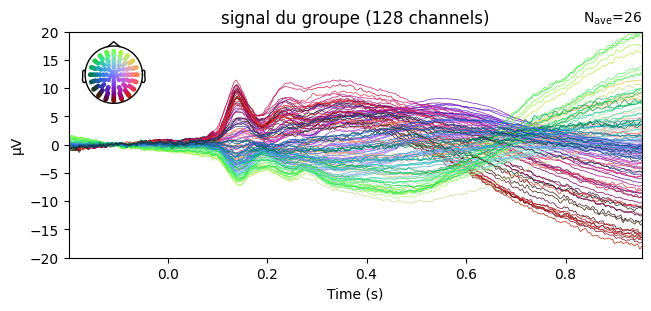

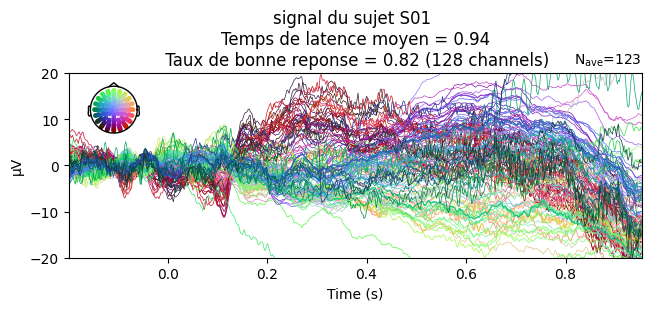

In [ ]:
list_RMSE = []
# array_RMSE_per_channel = []
list_mean_latency = []
list_good_answer_rate = []
list_bad_channels = []
list_pearson_r = []
list_pearson_p = []
list_var = []

list_subject = []
for sub_path in path_data:
    list_subject.append(find_participant(sub_path,signe = 'S'))

for sub in list_subject : #list_subject:
    if sub:
        train , test, mean_latency, good_answer_rate, bad_ch = make_evoked_split(path_directory=path_directory,subject_to_pop=subject_to_pop,subject_split= sub)
        print("=================================================")
        print("shape de test = ",test.data.shape)
        print("shape de train = ",train.data.shape)
        print("=================================================")

        list_RMSE.append(compute_RMSE(test,train,per_channel = False))
        # array_RMSE_per_channel.append((compute_RMSE(test,train,per_channel = True), test.info['bads']))
        list_mean_latency.append(mean_latency)
        list_good_answer_rate.append(good_answer_rate)
        list_bad_channels.append(bad_ch)
        # list_var.append(compute_var(train,test))
        
        train.plot(ylim=dict(eeg=(-20, 20)),
                   titles='signal du groupe')
        plt.show()

        test.plot(ylim=dict(eeg=(-20, 20)),
                  titles = f'signal du sujet {sub} \nTemps de latence moyen = {np.round(mean_latency,2)}\n Taux de bonne reponse = {np.round(good_answer_rate,2)}')
        plt.show()

        r, p_value = pearsonr(train.data.flatten(), test.data.flatten())
        list_pearson_r.append(r)
        list_pearson_p.append(p_value)

In [ ]:
# array_RMSE = np.array(array_RMSE_per_channel).mean(axis = 1)

# data = pd.DataFrame({
#     "sujets" : list_subject,
#     "RMSE" : array_RMSE * 10e6,
#     "bad_chs" : np.array(list_RMSE[1])
# })
# data = data.sort_values("RMSE")
# plt.title("distribution de l'erreur")
# sns.set(rc={"figure.figsize": (15, 8)})
# sns.barplot( y= data["RMSE"], x = data['sujets'], hue= data["bad_chs"])

# mediane = data["RMSE"].median()
# mean = data["RMSE"].mean()
# std = data["RMSE"].std() 
# max = data["RMSE"].max()
# min = data["RMSE"].min()

# print(f"stats : \nmediane = {mediane}\nmean = {mean}\nstd = {std}\n max = {max}\nmin = {min}")

In [ ]:
print(np.array(list_mean_latency).shape)
print(np.array(list_good_answer_rate).shape)


a = []
for el in list_bad_channels:
    a.append(len(el))

print(np.array(a).shape)

list_mean_latency = np.array(list_mean_latency).reshape((27))
list_good_answer_rate = np.array(list_good_answer_rate).reshape((27))

(27,)
(27,)
(27,)


In [ ]:
print(len(list_RMSE)) 
print(len(list_subject))
print(len(list_mean_latency))
print(len(list_good_answer_rate))
print(np.array(list_pearson_p).shape)
print(np.array(list_pearson_r).shape)
print(len(a))
list_pearson_r

27
27
27
27
(27,)
(27,)
27


[np.float64(0.30869966437438245),
 np.float64(0.513870053526177),
 np.float64(0.6939947157022469),
 np.float64(0.7000509248287355),
 np.float64(0.7220390218569559),
 np.float64(0.5537144619339478),
 np.float64(0.7159797034324658),
 np.float64(0.4937229086161423),
 np.float64(0.3431054550741573),
 np.float64(0.6427877281984457),
 np.float64(0.6364498407905022),
 np.float64(0.7763436441323942),
 np.float64(0.7018247425688382),
 np.float64(0.6846579605349626),
 np.float64(0.6196113828605327),
 np.float64(0.6063236031544956),
 np.float64(0.3077002669665523),
 np.float64(0.5972916201900247),
 np.float64(0.5280706402940416),
 np.float64(0.5776035856633974),
 np.float64(0.7775451495519531),
 np.float64(0.3524839478743383),
 np.float64(0.616084330949715),
 np.float64(0.6554183906535243),
 np.float64(0.6619394513802892),
 np.float64(0.4194375589100657),
 np.float64(0.7322250935900542)]

In [ ]:
data = pd.DataFrame({
    "sujets" : np.array(list_subject),
    "RMSE" : np.array(list_RMSE) * 10e6,
    "bad_chs" : np.array(a),
    "mean_latency" : np.array(list_mean_latency),
    "rate_good_answer" : np.array(list_good_answer_rate),
    "pearson_r" : np.array(list_pearson_r),
    "pearson_p" : np.array(list_pearson_p),
})

data = data.sort_values("RMSE")
plt.title("distribution de l'erreur")
sns.set(rc={"figure.figsize": (15, 8)})
sns.barplot( y= data["RMSE"], x = data['sujets'],hue= data["rate_good_answer"])
plt.title(label = f'Distribustion des score RMSE par sujet et par taux de bonne reponse (couleur)')

plt.errorbar(
    x=range(len(data)),
    y=data["RMSE"],
    yerr=np.std(data["RMSE"]),
    fmt='none',
    c='black',
    capsize=5
)

plt.legend()
plt.show()

data = data.sort_values("RMSE")
plt.title("distribution de l'erreur")
sns.set(rc={"figure.figsize": (15, 8)})
sns.barplot( y= data["RMSE"], x = data['sujets'],hue= data["mean_latency"])
plt.title(label = f'Distribustion des score RMSE par sujet et par temps de latence moyen (couleur)')

plt.errorbar(
    x=range(len(data)),
    y=data["RMSE"],
    yerr=np.std(data["RMSE"]),
    fmt='none',
    c='black',
    capsize=5
)

plt.legend()
plt.show()

data = data.sort_values("RMSE")
plt.title("distribution de l'erreur")
sns.set(rc={"figure.figsize": (15, 8)})
sns.barplot( y= data["RMSE"], x = data['sujets'],hue= data['bad_chs'],errorbar='sd')
plt.title(label = f'Distribustion des score RMSE par sujet et par nombre de canaux mauvais (couleur)')

plt.errorbar(
    x=range(len(data)),
    y=data["RMSE"],
    yerr= np.std(data["RMSE"]),
    fmt='none',
    c='black',
    capsize=5
)

plt.legend()
plt.show()

data = data.sort_values("RMSE")
plt.title("distribution de l'erreur")
sns.set(rc={"figure.figsize": (15, 8)})
sns.barplot( y= data["RMSE"], x = data['sujets'],hue= data['pearson_r'])
plt.title(label = f'Distribustion des score RMSE par sujet et par rapport a r de Pearson (couleur)')

plt.errorbar(
    x=range(len(data)),
    y=data["RMSE"],
    yerr=np.std(data["RMSE"]),
    fmt='none',
    c='black',
    capsize=5
)
plt.legend()
plt.show()


data = data.sort_values("mean_latency")
plt.title("distribution du temps de latence")
sns.set(rc={"figure.figsize": (15, 8)})
sns.barplot( y= data["mean_latency"], x = data['sujets'])
plt.title(label = f'Distribustion du temps dce latence moyen par sujet ')


mediane = data["RMSE"].median() 
mean = data["RMSE"].mean() 
std = data["RMSE"].std()
max = data["RMSE"].max()
min = data["RMSE"].min()
print(f"stats RMSE: \nmediane = {mediane}\nmean = {mean}\nstd = {std}\n max = {max}\nmin = {min}")

mediane = data["pearson_r"].median() 
mean = data["pearson_r"].mean() 
std = data["pearson_r"].std()
max = data["pearson_r"].max()
min = data["pearson_r"].min()

print(f"stats pearson_r: \nmediane = {mediane}\nmean = {mean}\nstd = {std}\n max = {max}\nmin = {min}")

NameError: name 'pd' is not defined

In [ ]:
data = data.sort_values("pearson_r")
plt.title("distribution de l'erreur")
sns.set(rc={"figure.figsize": (15, 8)})
sns.barplot( y= data["pearson_r"], x = data['sujets'],hue= data["rate_good_answer"])
plt.title(label = f'Distribustion des score pearson_r par sujet et par taux de bonne reponse (couleur)')

plt.errorbar(
    x=range(len(data)),
    y=data["pearson_r"],
    yerr=np.std(data["pearson_r"]),
    fmt='none',
    c='black',
    capsize=5
)

plt.legend()
plt.show()

plt.title("distribution de l'erreur")
sns.set(rc={"figure.figsize": (15, 8)})
sns.barplot( y= data["pearson_r"], x = data['sujets'],hue= data["mean_latency"])
plt.title(label = f'Distribustion des score pearson_r par sujet et par temps de latence moyen (couleur)')

plt.errorbar(
    x=range(len(data)),
    y=data["pearson_r"],
    yerr=np.std(data["pearson_r"]),
    fmt='none',
    c='black',
    capsize=5
)

plt.legend()
plt.show()

plt.title("distribution de l'erreur")
sns.set(rc={"figure.figsize": (15, 8)})
sns.barplot( y= data["pearson_r"], x = data['sujets'],hue= data['bad_chs'],errorbar='sd')
plt.title(label = f'Distribustion des score pearson_r par sujet et par nombre de canaux mauvais (couleur)')

plt.errorbar(
    x=range(len(data)),
    y=data["pearson_r"],
    yerr= np.std(data["pearson_r"]),
    fmt='none',
    c='black',
    capsize=5
)

plt.legend()
plt.show()

plt.title("distribution de l'erreur")
sns.set(rc={"figure.figsize": (15, 8)})
sns.barplot( y= data["pearson_r"], x = data['sujets'],hue= data['pearson_r'])
plt.title(label = f'Distribustion des score pearson_r par sujet et par rapport a r de Pearson (couleur)')

plt.errorbar(
    x=range(len(data)),
    y=data["pearson_r"],
    yerr=np.std(data["pearson_r"]),
    fmt='none',
    c='black',
    capsize=5
)
plt.legend()
plt.show()



NameError: name 'data' is not defined

In [ ]:
from scipy.stats import pearsonr

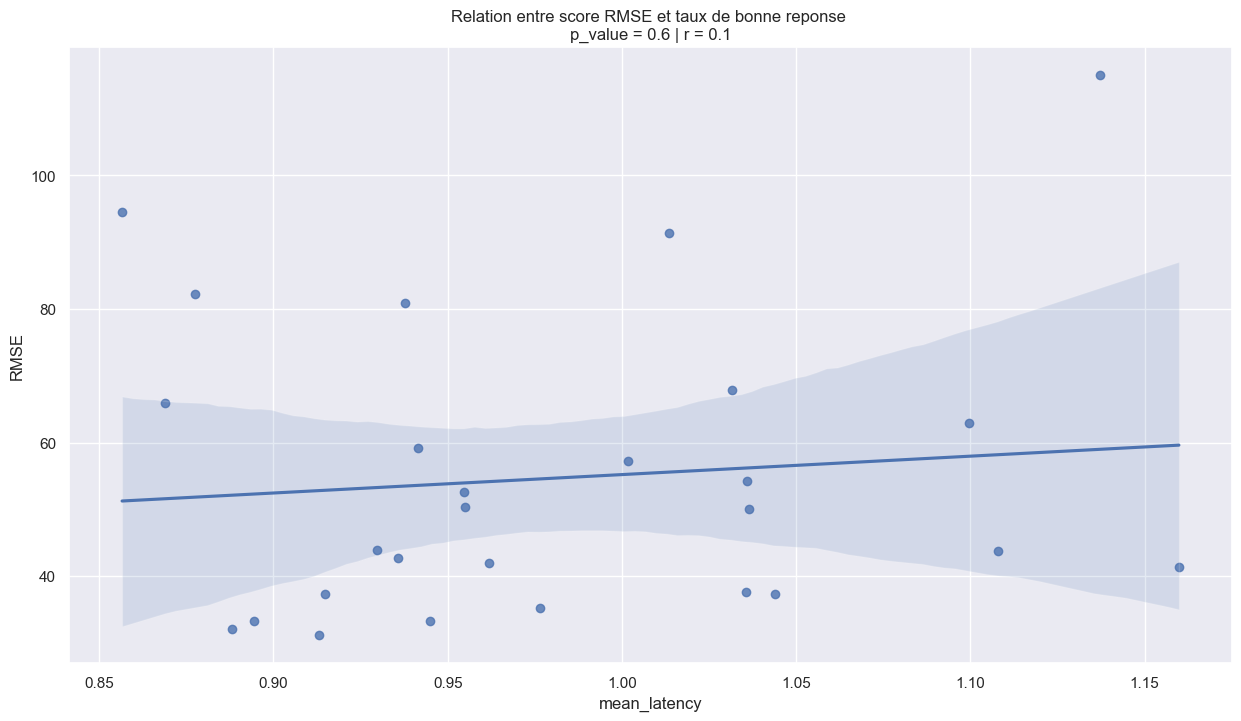

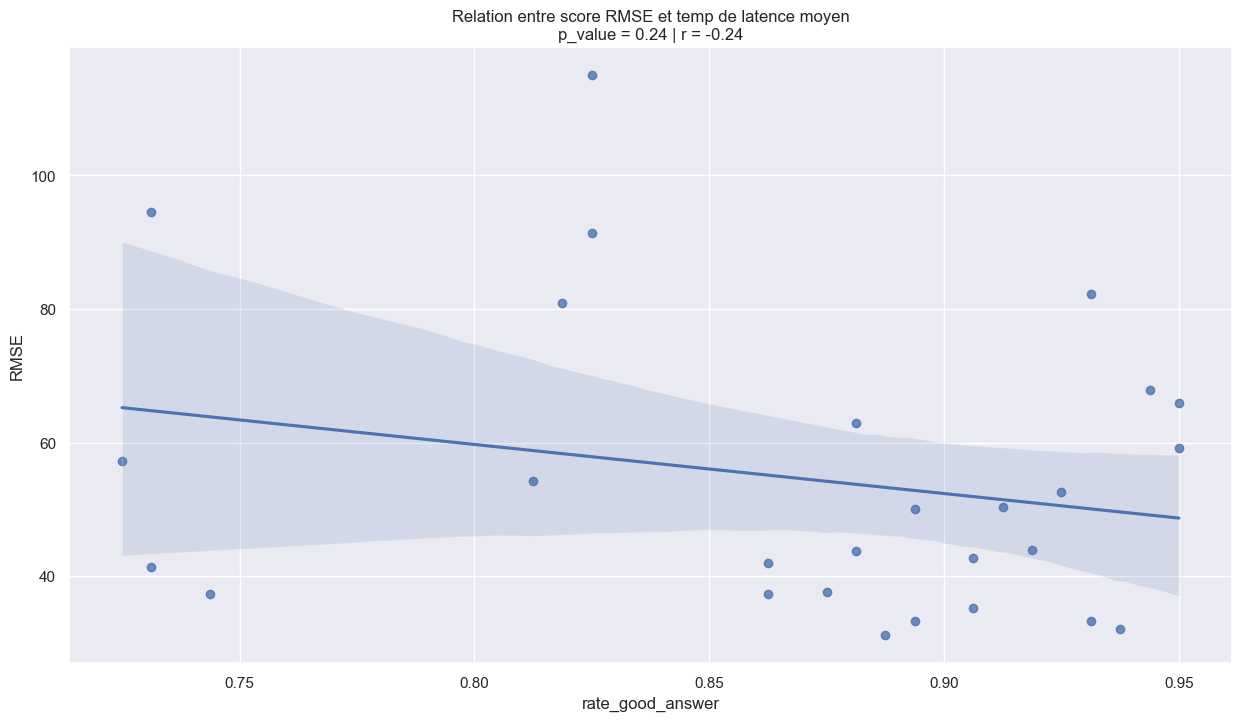

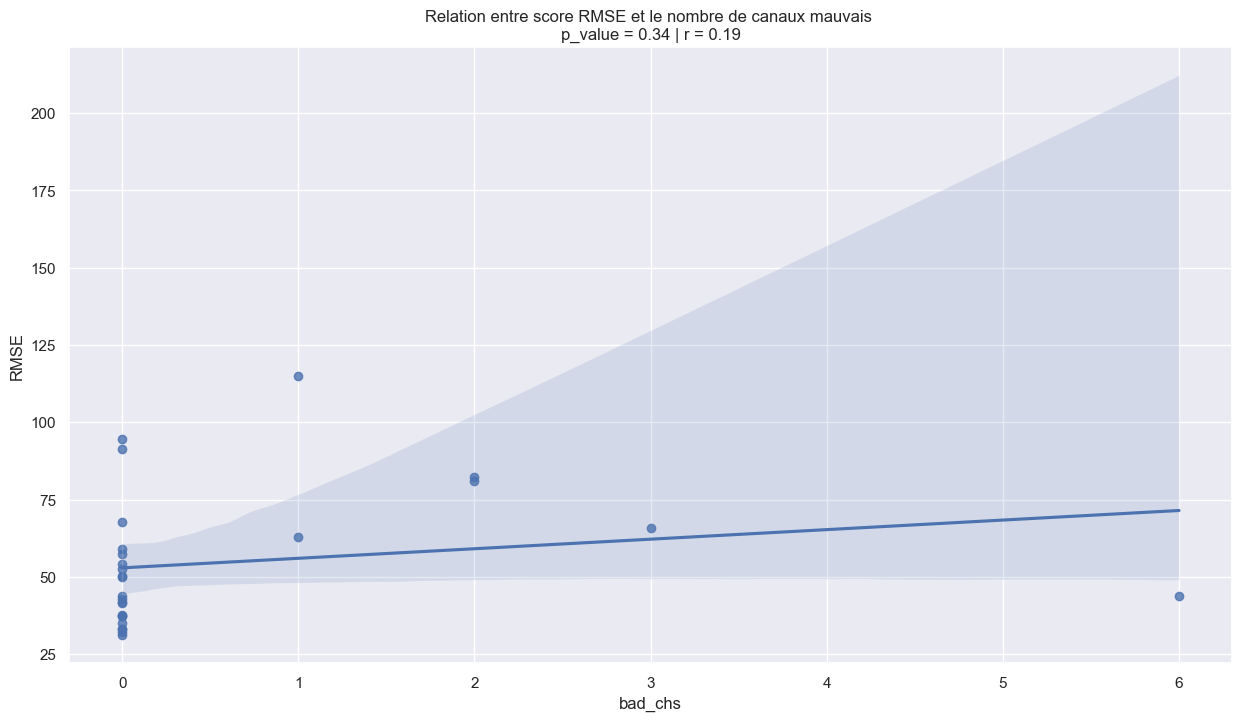

Text(0.5, 1.0, 'Relation entre score RMSE et le r de pearson \np_value = 0.01 | r = -0.47')

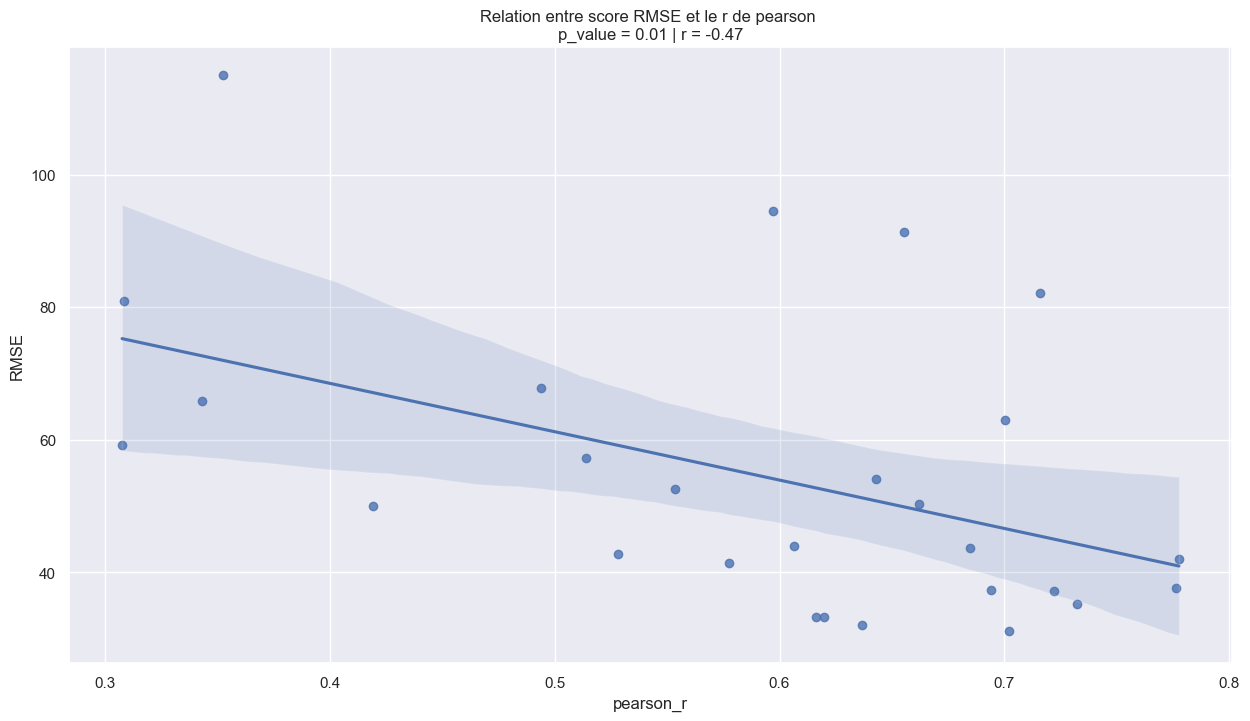

In [ ]:
corr, p = pearsonr(data["RMSE"],data["mean_latency"])
sns.regplot(y= data["RMSE"], x = data["mean_latency"])
plt.title(label = f"Relation entre score RMSE et taux de bonne reponse \np_value = {np.round(p,2)} | r = {np.round(corr,2)}")

plt.show()
corr, p = pearsonr(data["RMSE"],data["rate_good_answer"])
sns.regplot(y= data["RMSE"], x = data['rate_good_answer'])
plt.title(label = f"Relation entre score RMSE et temp de latence moyen\np_value = {np.round(p,2)} | r = {np.round(corr,2)}")
plt.show()

corr, p = pearsonr(data["RMSE"],data["bad_chs"])
sns.regplot(y= data["RMSE"], x = data["bad_chs"])
plt.title(label = f"Relation entre score RMSE et le nombre de canaux mauvais \np_value = {np.round(p,2)} | r = {np.round(corr,2)}")

plt.show()

corr, p = pearsonr(data["RMSE"],data["pearson_r"])
sns.regplot(y= data["RMSE"], x = data["pearson_r"])
plt.title(label = f"Relation entre score RMSE et le r de pearson \np_value = {np.round(p,2)} | r = {np.round(corr,2)}")

